# Diffusion Map Embedding of Hippocampal Connectivity Fingerprints

Diffusion map embedding (Coifman & Lafon 2006) applied to the bilateral rat connectome,
in the **connectivity-gradient** style of Katsumi et al. (2023) / Margulies et al. (2016).

**What we embed.** We take the two `7 × 72` hippocampal connectivity blocks — rows are the
**7 HPC subfields**, columns the **72 shared partner regions**. Each partner region is
therefore a **7-dimensional connectivity fingerprint** (its connection strengths to the 7
subfields). We treat the **7 subfields as the feature dimensions** and embed the **72
partner regions**: we build a `72 × 72` affinity matrix between partners from their 7-D
fingerprints, then diffusion-map-embed it. The output is a set of **gradients over the 72
partners**, ordering them by their hippocampal connectivity profile.

We do this for both directions, separately:

- **afferent** — partner → HPC (what the hippocampus *receives*),
- **efferent** — HPC → partner (what the hippocampus *sends*),

and under **two affinity kernels**, as two separate analyses:

- **Analysis 1 — cosine similarity** (α = 0.5, multiscale diffusion time),
- **Analysis 2 — normalized angle** (α = 0.5, multiscale diffusion time).

## The method (Coifman–Lafon diffusion maps)

Given a symmetric, non-negative affinity matrix `W` between the `n = 72` partners:

1. **Anisotropic normalization** with `alpha`: `W_a = D^{-a} W D^{-a}`, where `D` is the
   degree (row-sum) diagonal. `alpha = 0.5` (the Fokker–Planck normalization used in the
   gradient literature) removes the influence of sampling density on the geometry.
2. **Markov transition matrix** `P = D_a^{-1} W_a` (row-stochastic). We eigendecompose the
   symmetric `S = D_a^{-1/2} W_a D_a^{-1/2}` (numerically stable) and map back to the right
   eigenvectors `psi_k` of `P`. The largest eigenvalue is `lambda_0 = 1` with a constant
   eigenvector (dropped).
3. **Diffusion coordinates.** Gradient `k` = `lambda_k^t * psi_k`. With **multiscale**
   diffusion time (`t = 0` convention) the scaling is `lambda_k / (1 - lambda_k)`, which
   weights each component by how slowly it mixes.

**Affinity kernels.**

- *Cosine similarity* of the 7-D fingerprints. Because the fingerprints live in 7-D, the
  cosine affinity is a Gram matrix of **rank ≤ 7**, so the embedding has at most ~6–7
  non-trivial gradients (the same ceiling that bounds PCA here).
- *Normalized angle*, `1 − arccos(cosine)/π` — Margulies' alternative kernel. The `arccos`
  is a monotone but non-linear transform, so this matrix is **not** rank-limited to 7 and
  yields a fuller spectrum. There is a caveat specific to our data, though: the fingerprints
  are **non-negative**, so cosine ∈ [0, 1] and the normalized angle lands in **[0.5, 1]** —
  a compressed range that makes every partner look fairly similar to every other and
  therefore *flattens* the diffusion spectrum (we see this concretely in Analysis 2).
  Margulies' cortical use has signed correlations (cosine ∈ [−1, 1]), where this compression
  does not arise.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.metrics.pairwise import cosine_similarity

from helpers import log_weight_transform, get_feature_vectors_shared_hpc

# --- Data: 7 x 72 afferent / efferent blocks over the shared partners ---
df_afferent, df_efferent = get_feature_vectors_shared_hpc()   # index = 7 HPC subfields, cols = 72 partners
partners = list(df_efferent.columns)
subfields = list(df_efferent.index)

# Log-weight transform (Faskowitz & Sporns), then transpose so rows = 72 partners
# (samples) and columns = 7 subfields (feature dimensions).
X_aff = log_weight_transform(df_afferent.values).T    # 72 x 7 fingerprints (partner -> HPC)
X_eff = log_weight_transform(df_efferent.values).T    # 72 x 7 fingerprints (HPC -> partner)
print('afferent fingerprints:', X_aff.shape, '| efferent fingerprints:', X_eff.shape,
      '| subfields (dims):', subfields)


# --- Affinity kernels ---
def cosine_affinity(X):
    # Cosine similarity between partners' 7-D fingerprints; non-negative for non-negative X.
    return np.clip(cosine_similarity(X), -1.0, 1.0)

def normalized_angle_affinity(X):
    # Margulies' normalized-angle kernel: 1 - arccos(cosine)/pi.
    c = np.clip(cosine_similarity(X), -1.0, 1.0)
    return 1.0 - np.arccos(c) / np.pi


# --- Diffusion map (Coifman & Lafon 2006) ---
def compute_diffusion_map(affinity, alpha=0.5, diffusion_time=0):
    L = np.asarray(affinity, dtype=float)
    d  = L.sum(1)
    da = np.power(d, -alpha)
    La = da[:, None] * L * da[None, :]                 # anisotropic (alpha) normalization
    d2 = La.sum(1)
    inv_sqrt = 1.0 / np.sqrt(d2)
    S = inv_sqrt[:, None] * La * inv_sqrt[None, :]     # symmetric, similar to Markov P
    vals, vecs = np.linalg.eigh(S)
    order = np.argsort(vals)[::-1]
    vals, vecs = vals[order], vecs[:, order]
    psi = vecs * inv_sqrt[:, None]                     # right eigenvectors of P
    psi = psi / psi[:, 0][:, None]                     # normalize trivial (constant) component
    if diffusion_time == 0:
        scale = vals[1:] / (1.0 - vals[1:])            # multiscale diffusion time
    else:
        scale = vals[1:] ** diffusion_time
    embedding = psi[:, 1:] * scale[None, :]            # drop trivial component 0
    return embedding, vals


def run_embedding(X, affinity_fn, alpha=0.5, diffusion_time=0):
    A = affinity_fn(X)
    emb, lam = compute_diffusion_map(A, alpha=alpha, diffusion_time=diffusion_time)
    return A, emb, lam


def plot_embedding(emb, lam, partners, title, n_scree=10):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
    k = min(n_scree, len(lam) - 1)
    axes[0].plot(range(1, k + 1), lam[1:k + 1], 'o-')
    axes[0].set_xlabel('diffusion component'); axes[0].set_ylabel(r'eigenvalue $\lambda$')
    axes[0].set_title('Eigenvalue spectrum (trivial $\\lambda_0=1$ dropped)')
    axes[0].set_ylim(0, 1.02); axes[0].set_xticks(range(1, k + 1))

    g1, g2 = emb[:, 0], emb[:, 1]
    sc = axes[1].scatter(g1, g2, c=g1, cmap='coolwarm', s=45, edgecolor='k', linewidth=0.3)
    plt.colorbar(sc, ax=axes[1], fraction=0.045, pad=0.02, label='Gradient 1')
    axes[1].axhline(0, color='gray', lw=0.5); axes[1].axvline(0, color='gray', lw=0.5)
    axes[1].set_xlabel('Gradient 1'); axes[1].set_ylabel('Gradient 2')
    axes[1].set_title('Diffusion embedding of the 72 partners')
    order = np.argsort(g1)
    for idx in list(order[:4]) + list(order[-4:]):        # label G1 extremes
        axes[1].annotate(partners[idx], (g1[idx], g2[idx]), fontsize=8,
                         xytext=(3, 3), textcoords='offset points')
    fig.suptitle(title, fontsize=14, y=1.02); fig.tight_layout(); plt.show()


def gradient_extremes(emb, partners, grad=0, n=8):
    order = np.argsort(emb[:, grad])
    lo = [f'{partners[i]} ({emb[i, grad]:+.3f})' for i in order[:n]]
    hi = [f'{partners[i]} ({emb[i, grad]:+.3f})' for i in order[::-1][:n]]
    return pd.DataFrame({f'G{grad+1} low end': lo, f'G{grad+1} high end': hi})

afferent fingerprints: (72, 7) | efferent fingerprints: (72, 7) | subfields (dims): ['DG', 'CA3', 'CA2', 'CA1v', 'CA1d', 'SUBv', 'SUBd']


---
## Analysis 1 — Cosine-similarity affinity kernel

Affinity = **cosine similarity** between the 72 partners' 7-D fingerprints; diffusion map
with **α = 0.5** and **multiscale** diffusion time. Run separately on afferent and efferent.
Recall the cosine affinity is rank ≤ 7, so expect only ~6–7 non-trivial gradients.

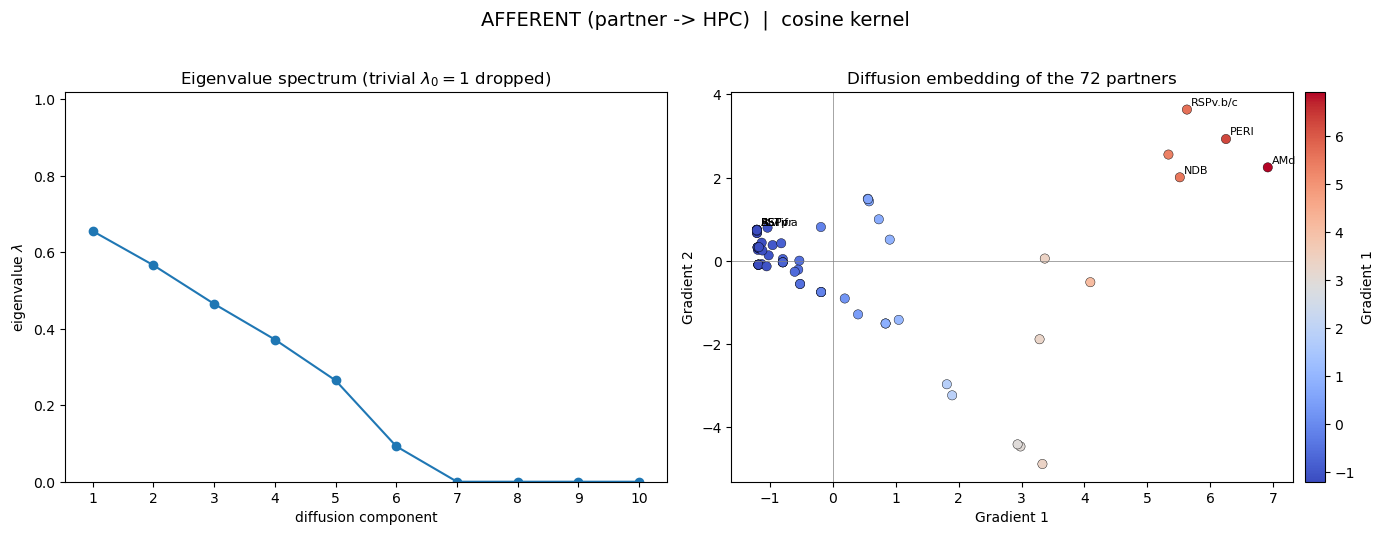

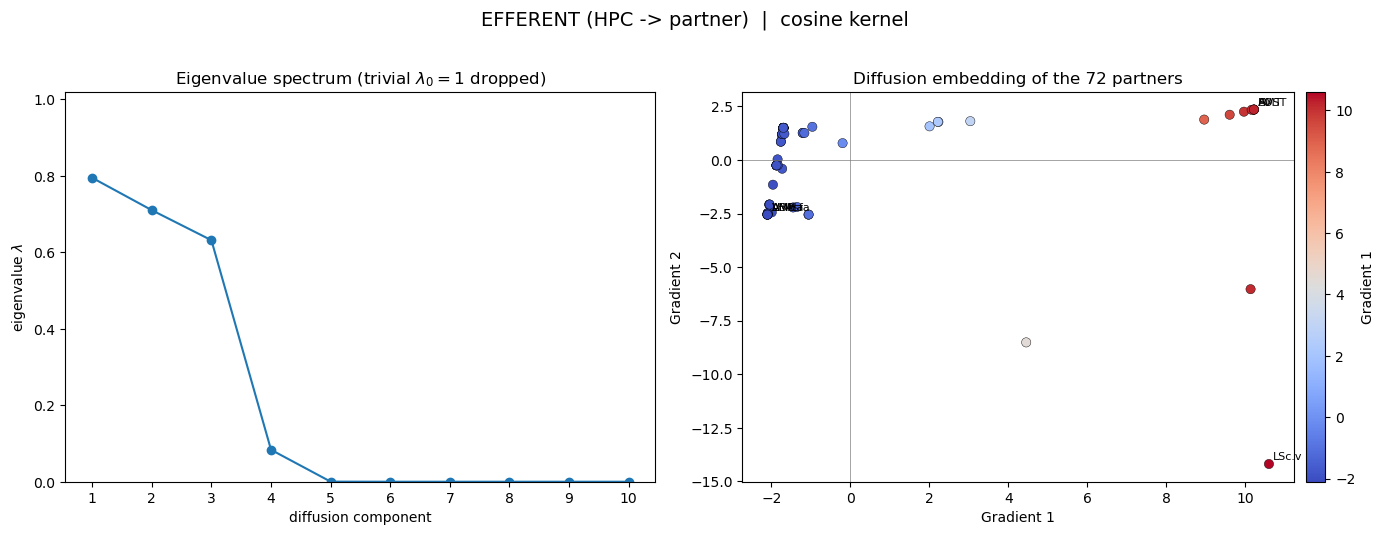

Gradient-1 extremes (cosine kernel)

AFFERENT:
     G1 low end       G1 high end
RSPv.a (-1.208)      AMd (+6.914)
 BSTpr (-1.208)     PERI (+6.250)
 BSTif (-1.208) RSPv.b/c (+5.629)
   AIv (-1.208)      NDB (+5.516)
 BSTam (-1.208)      IAM (+5.335)
   PVT (-1.207)     ENTm (+4.093)
   EPv (-1.207)    LSc.d (+3.369)
  BMAa (-1.206)     POST (+3.332)

EFFERENT:
     G1 low end     G1 high end
   ADP (-2.102) LSc.v (+10.605)
  VMHa (-2.102)   SMT (+10.225)
   AMd (-2.102)    AV (+10.225)
LHAsfa (-2.102)  POST (+10.225)
  BMAa (-2.100)  RSPd (+10.221)
   AAA (-2.097)   IAM (+10.167)
    LA (-2.095) LSc.d (+10.139)
  BLAa (-2.095)    ECT (+9.972)


In [2]:
A_aff_cos, emb_aff_cos, lam_aff_cos = run_embedding(X_aff, cosine_affinity)
plot_embedding(emb_aff_cos, lam_aff_cos, partners, 'AFFERENT (partner -> HPC)  |  cosine kernel')

A_eff_cos, emb_eff_cos, lam_eff_cos = run_embedding(X_eff, cosine_affinity)
plot_embedding(emb_eff_cos, lam_eff_cos, partners, 'EFFERENT (HPC -> partner)  |  cosine kernel')

print('Gradient-1 extremes (cosine kernel)\n')
print('AFFERENT:'); print(gradient_extremes(emb_aff_cos, partners, 0).to_string(index=False))
print('\nEFFERENT:'); print(gradient_extremes(emb_eff_cos, partners, 0).to_string(index=False))

---
## Analysis 2 — Normalized-angle affinity kernel

Identical pipeline, but affinity = **normalized angle** `1 − arccos(cosine)/π` (Margulies'
kernel); **α = 0.5**, **multiscale**. Because `arccos` is non-linear, this affinity is not
rank-limited to 7, so its eigenvalue spectrum has a longer tail than the cosine one.

However — as flagged in the method section — our fingerprints are non-negative, so the
normalized angle is squeezed into **[0.5, 1]**. That compression **flattens** the spectrum
here (λ₁ ≈ 0.12–0.20, versus cosine's ≈ 0.66–0.80), so the leading gradient is only weakly
separated and, as the comparison section shows, does **not** closely match the cosine
gradient. We include this kernel as the requested second analysis and to make the effect
explicit; for this dataset the cosine kernel is the more informative choice.

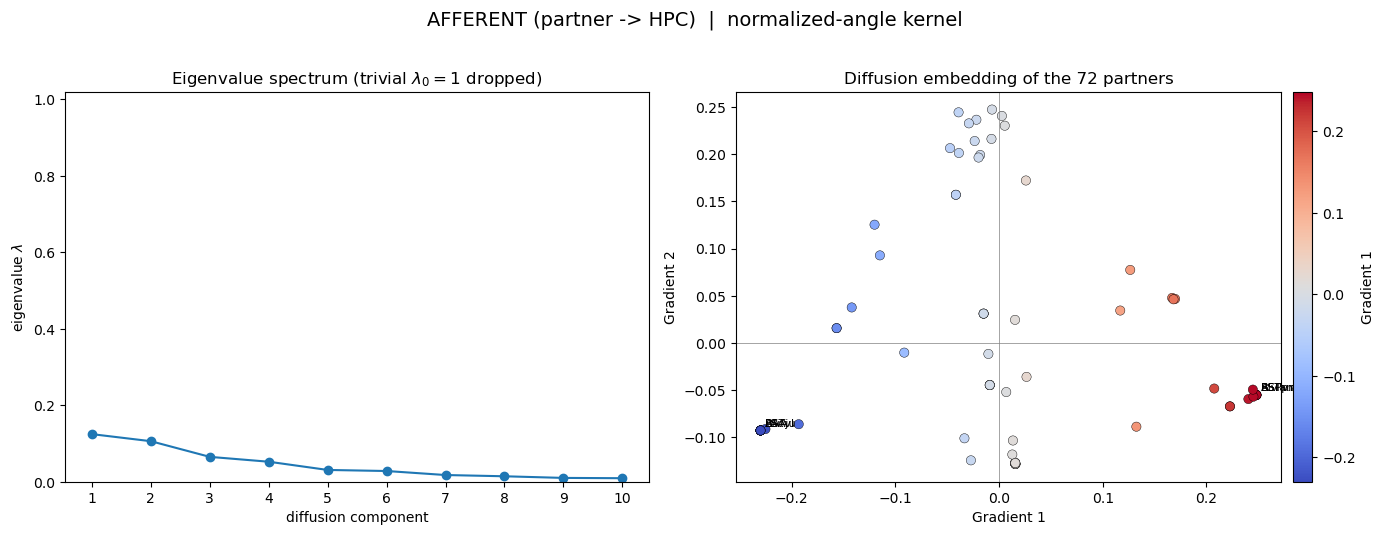

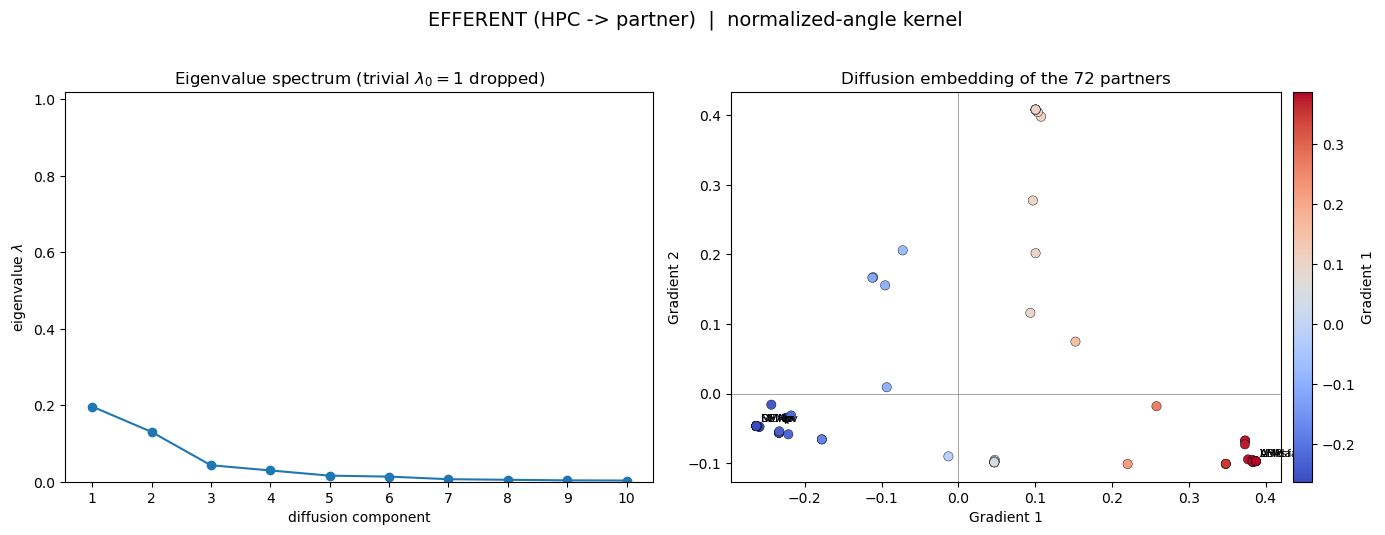

Gradient-1 extremes (normalized-angle kernel)

AFFERENT:
     G1 low end     G1 high end
 BSTju (-0.230)  BSTam (+0.248)
LSr.vl (-0.230)  BSTpr (+0.248)
   PAA (-0.230) RSPv.a (+0.248)
   AAA (-0.230)    AIv (+0.248)
 BSTtr (-0.230)  BSTif (+0.248)
  BSTd (-0.230)    PVT (+0.245)
  VMHa (-0.230)     AV (+0.245)
  MPNm (-0.230)    EPv (+0.240)

EFFERENT:
    G1 low end     G1 high end
 DMHp (-0.263)    ADP (+0.387)
 DMHv (-0.263)   VMHa (+0.387)
 SUMm (-0.263) LHAsfa (+0.387)
MEApv (-0.263)    AMd (+0.387)
 MPNm (-0.263)   BMAa (+0.386)
 BSTd (-0.263)    AAA (+0.384)
  LSv (-0.263)   BLAa (+0.383)
BSTju (-0.263)     LA (+0.383)


In [3]:
A_aff_na, emb_aff_na, lam_aff_na = run_embedding(X_aff, normalized_angle_affinity)
plot_embedding(emb_aff_na, lam_aff_na, partners, 'AFFERENT (partner -> HPC)  |  normalized-angle kernel')

A_eff_na, emb_eff_na, lam_eff_na = run_embedding(X_eff, normalized_angle_affinity)
plot_embedding(emb_eff_na, lam_eff_na, partners, 'EFFERENT (HPC -> partner)  |  normalized-angle kernel')

print('Gradient-1 extremes (normalized-angle kernel)\n')
print('AFFERENT:'); print(gradient_extremes(emb_aff_na, partners, 0).to_string(index=False))
print('\nEFFERENT:'); print(gradient_extremes(emb_eff_na, partners, 0).to_string(index=False))

---
## Comparison: kernels and directions

Diffusion-map gradients are only defined up to sign and scale, so we compare them with
**|Spearman rank correlation|** of Gradient 1:

- **cosine vs normalized-angle** (same direction) — would be high if the leading gradient
  were robust to the kernel choice. Here it is only **moderate (~0.28)**, because the
  normalized-angle spectrum is flattened by the [0.5, 1] compression on non-negative data —
  its Gradient 1 is weakly defined.
- **afferent vs efferent** (same kernel) — the biologically interesting contrast: do
  partners order the same way by what they *send* to vs *receive* from the hippocampus?
  Read this off the **cosine** row (the reliable kernel).

In [4]:
def absrho(a, b):
    return abs(spearmanr(a, b).correlation)

print('Gradient 1 |Spearman| comparisons')
print('  cosine vs normalized-angle :  afferent %.3f | efferent %.3f'
      % (absrho(emb_aff_cos[:, 0], emb_aff_na[:, 0]),
         absrho(emb_eff_cos[:, 0], emb_eff_na[:, 0])))
print('  afferent vs efferent       :  cosine   %.3f | normalized-angle %.3f'
      % (absrho(emb_aff_cos[:, 0], emb_eff_cos[:, 0]),
         absrho(emb_aff_na[:, 0], emb_eff_na[:, 0])))

# Number of non-trivial (positive) eigenvalues per analysis -- the effective gradient count.
for tag, lam in [('afferent cosine', lam_aff_cos), ('efferent cosine', lam_eff_cos),
                 ('afferent norm-angle', lam_aff_na), ('efferent norm-angle', lam_eff_na)]:
    print(f'  {tag:22s}: {int((lam > 1e-10).sum())} positive eigenvalues '
          f'(lambda_1..3 = {np.round(lam[1:4], 3)})')

Gradient 1 |Spearman| comparisons
  cosine vs normalized-angle :  afferent 0.285 | efferent 0.276
  afferent vs efferent       :  cosine   0.444 | normalized-angle 0.027
  afferent cosine       : 7 positive eigenvalues (lambda_1..3 = [0.656 0.566 0.465])
  efferent cosine       : 6 positive eigenvalues (lambda_1..3 = [0.795 0.71  0.632])
  afferent norm-angle   : 48 positive eigenvalues (lambda_1..3 = [0.124 0.106 0.065])
  efferent norm-angle   : 46 positive eigenvalues (lambda_1..3 = [0.197 0.13  0.043])


**Notes / caveats.**

- The **cosine** analysis is capped at ~6–7 non-trivial gradients by the 7-D fingerprint
  space, with a clearly separated leading gradient (λ₁ ≈ 0.66–0.80). The **normalized-angle**
  analysis has a longer spectral tail but, on these non-negative fingerprints, a **flattened**
  spectrum (λ₁ ≈ 0.12–0.20); its leading gradient is weakly defined and only moderately
  correlated with the cosine one (|Spearman| ≈ 0.28). For this dataset the **cosine kernel is
  the more informative choice**. Interpret only the first few gradients either way.
- Under the (more reliable) cosine kernel, the afferent and efferent leading gradients
  correlate only **moderately (|Spearman| ≈ 0.44)** — partners are ordered somewhat, but far
  from identically, by what the hippocampus *receives from* vs *sends to* them, echoing the
  send/receive asymmetry seen elsewhere in this project.
- Gradients are sign- and scale-arbitrary; only the *ordering* of partners along a gradient
  is meaningful.
- To relate gradients to anatomy, color the scatter by each partner's major division
  (`data/label_major_division_mapping.csv`) — an easy extension of `plot_embedding`.
- This mirrors the connectivity-gradient pipeline (Margulies/Katsumi): affinity → anisotropic
  diffusion → leading eigenvectors as smooth gradients over the connected regions.

---
## BrainSpace toolbox: diffusion maps, with and without row-thresholding

The analyses above used a from-scratch diffusion map. Here we reproduce the embedding with
the **BrainSpace** toolbox (`GradientMaps`, `approach='dm'`, `kernel='cosine'`), run on the
afferent then efferent 7-D fingerprints, under **two pipelines**:

- **top-10% row threshold** — keep only the largest 10% of affinities in each row
  (`sparsity=0.9`, via BrainSpace's `dominant_set`); a kNN-style sparsification common in the
  gradient literature (Margulies et al.);
- **no threshold** — the full cosine affinity.

**Implementation note.** BrainSpace's default `GradientMaps.fit(x, sparsity=0.9)` sparsifies
the *columns of the input* before building the affinity. Our input has only 7 columns (the
subfields), so 10% rounds to zero and it raises `Cannot select 0 elements`. We therefore
build the cosine affinity first and threshold the resulting **72×72** matrix
(`compute_affinity(..., pre_sparsify=False)`), then embed with `kernel=None`. The
row-thresholded affinity is **asymmetric** by construction (thresholding is per row), as
requested.

As a check, the **no-threshold** BrainSpace Gradient 1 is compared to the from-scratch cosine
Gradient 1 from Analysis 1 — they should be near-identical.

afferent | top-10% row threshold: affinity (72, 72), 10% non-zero, symmetric=False


/opt/anaconda3/envs/br2f/lib/python3.12/site-packages/brainspace/gradient/embedding.py:101: UserWarning: Affinity is not symmetric. Making symmetric.
  warnings.warn('Affinity is not symmetric. Making symmetric.')


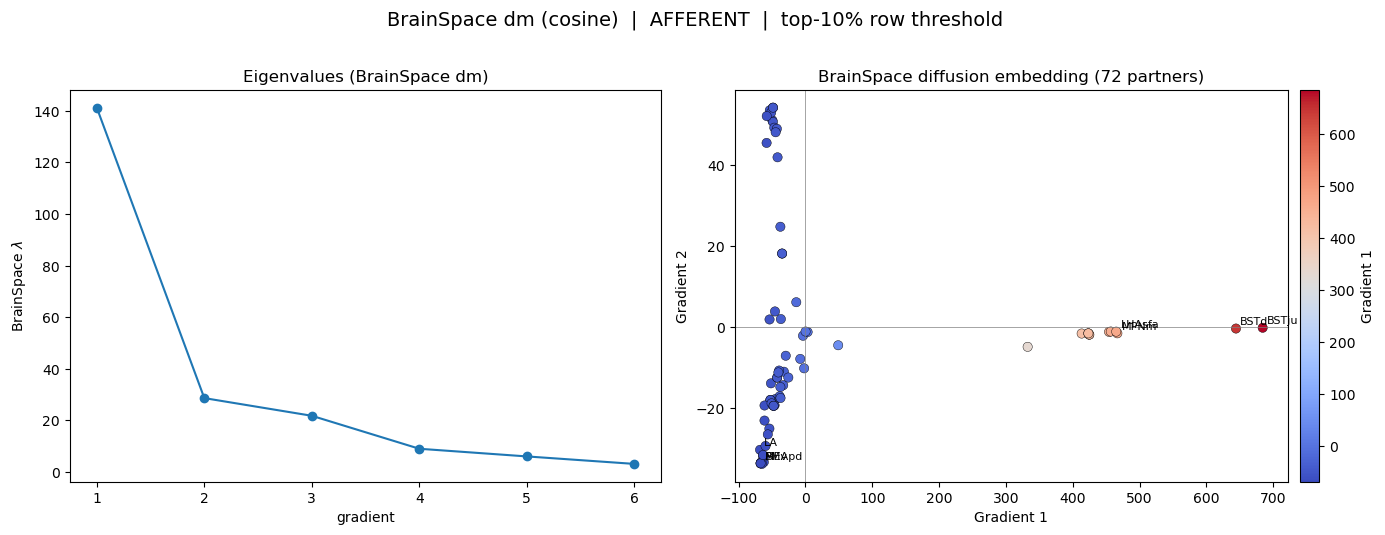

afferent | no threshold: affinity (72, 72), 87% non-zero, symmetric=True


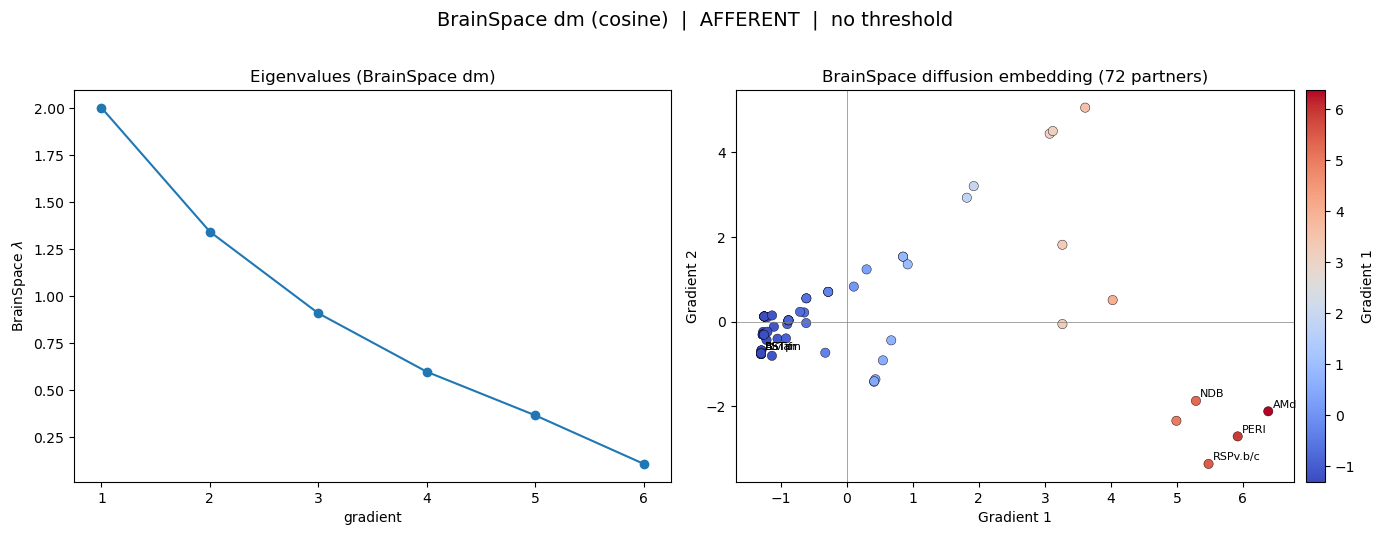

efferent | top-10% row threshold: affinity (72, 72), 10% non-zero, symmetric=False


/opt/anaconda3/envs/br2f/lib/python3.12/site-packages/brainspace/gradient/embedding.py:101: UserWarning: Affinity is not symmetric. Making symmetric.
  warnings.warn('Affinity is not symmetric. Making symmetric.')


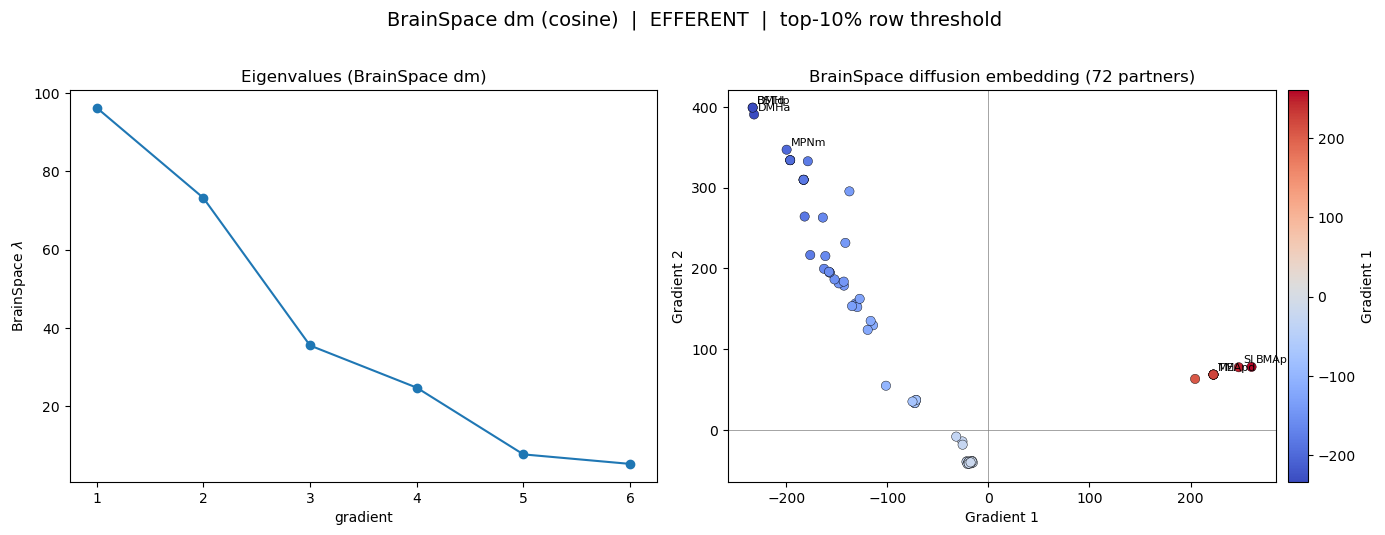

efferent | no threshold: affinity (72, 72), 92% non-zero, symmetric=True


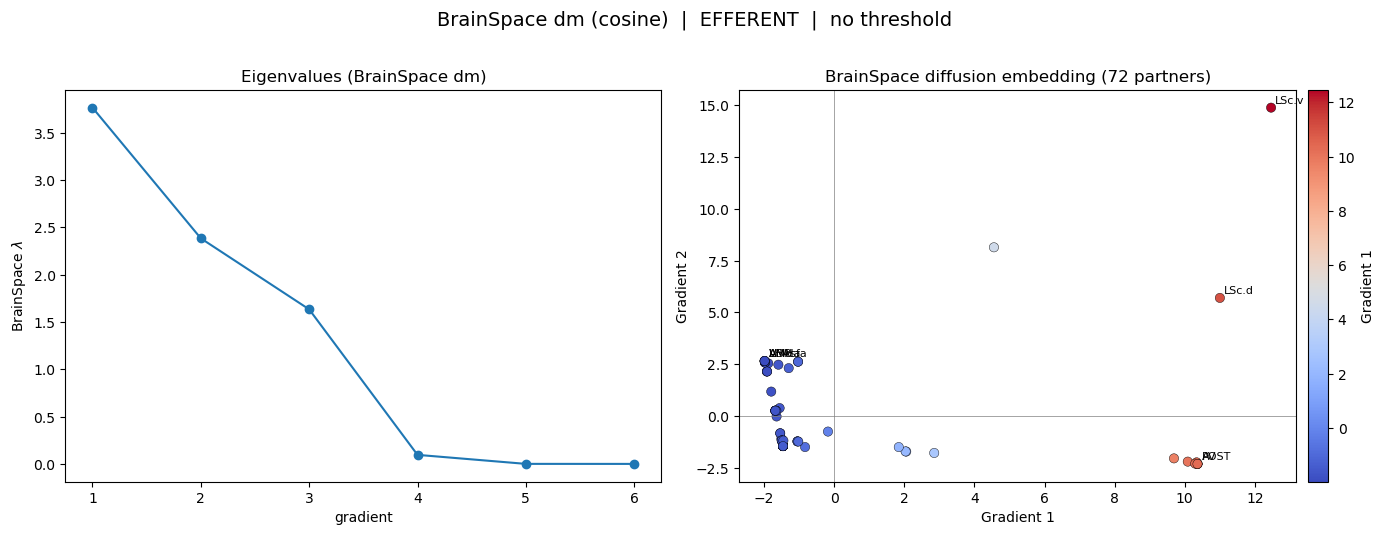


Validation -- |Spearman| of Gradient 1, BrainSpace(no threshold) vs custom cosine:
  afferent: 0.996 | efferent: 0.983


In [5]:
import scipy.sparse as sp
from brainspace.gradient import GradientMaps
from brainspace.gradient.kernels import compute_affinity


def brainspace_dm(X, threshold, n_components=6, seed=0):
    # Cosine affinity via BrainSpace, sparsifying the 72x72 affinity (not the 7-feature input).
    sparsity = 0.9 if threshold else None            # 0.9 -> keep top 10% of each row
    aff = compute_affinity(X, kernel='cosine', sparsity=sparsity, pre_sparsify=False)
    if sp.issparse(aff):
        aff = aff.toarray()
    gm = GradientMaps(n_components=n_components, approach='dm', kernel=None, random_state=seed)
    gm.fit(aff, sparsity=None)                        # affinity already built + thresholded
    return gm, aff


def plot_brainspace(gm, partners, title):
    grad, lam = gm.gradients_, gm.lambdas_
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
    k = min(6, len(lam))
    axes[0].plot(range(1, k + 1), lam[:k], 'o-')
    axes[0].set_xlabel('gradient'); axes[0].set_ylabel(r'BrainSpace $\lambda$')
    axes[0].set_title('Eigenvalues (BrainSpace dm)'); axes[0].set_xticks(range(1, k + 1))
    g1, g2 = grad[:, 0], grad[:, 1]
    sc = axes[1].scatter(g1, g2, c=g1, cmap='coolwarm', s=45, edgecolor='k', linewidth=0.3)
    plt.colorbar(sc, ax=axes[1], fraction=0.045, pad=0.02, label='Gradient 1')
    axes[1].axhline(0, color='gray', lw=0.5); axes[1].axvline(0, color='gray', lw=0.5)
    axes[1].set_xlabel('Gradient 1'); axes[1].set_ylabel('Gradient 2')
    axes[1].set_title('BrainSpace diffusion embedding (72 partners)')
    order = np.argsort(g1)
    for idx in list(order[:4]) + list(order[-4:]):
        axes[1].annotate(partners[idx], (g1[idx], g2[idx]), fontsize=8,
                         xytext=(3, 3), textcoords='offset points')
    fig.suptitle(title, fontsize=14, y=1.02); fig.tight_layout(); plt.show()


bs = {}
for name, X in [('afferent', X_aff), ('efferent', X_eff)]:
    for thr in (True, False):
        gm, aff = brainspace_dm(X, thr)
        bs[(name, thr)] = gm
        tag = 'top-10% row threshold' if thr else 'no threshold'
        nz = (aff > 0).mean()
        print(f'{name} | {tag}: affinity {aff.shape}, {100*nz:.0f}% non-zero, '
              f'symmetric={np.allclose(aff, aff.T)}')
        plot_brainspace(gm, partners, f'BrainSpace dm (cosine)  |  {name.upper()}  |  {tag}')

# Cross-check: BrainSpace (no threshold) vs the from-scratch cosine Gradient 1 (Analysis 1).
print('\nValidation -- |Spearman| of Gradient 1, BrainSpace(no threshold) vs custom cosine:')
print('  afferent: %.3f | efferent: %.3f' % (
    abs(spearmanr(bs[('afferent', False)].gradients_[:, 0], emb_aff_cos[:, 0]).correlation),
    abs(spearmanr(bs[('efferent', False)].gradients_[:, 0], emb_eff_cos[:, 0]).correlation)))